# Economic Indicators & S&P 500 Sector Analysis

## Setup

### Install & Import Libraries

In [1]:
!pip install yfinance

import sqlite3
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

### Download Sector ETF Data

In [2]:
tickers = ['XLK', 'XLF', 'XLE', 'XLV', 'XLY', 'XLP', 'XLI', 'XLU']

sector_names = {
    'XLK': 'Technology',
    'XLF': 'Financials',
    'XLE': 'Energy',
    'XLV': 'Healthcare',
    'XLY': 'Consumer Discretionary',
    'XLP': 'Consumer Staples',
    'XLI': 'Industrials',
    'XLU': 'Utilities'
}

all_sectors = []

for ticker in tickers:
    df = yf.download(ticker, start='2000-01-01', end='2026-01-01', interval='1mo')
    df = df[['Close', 'Volume']].copy()
    df.columns = ['avg_price', 'volume']
    df['sector'] = sector_names[ticker]
    df['date'] = df.index.strftime('%Y-%m-%d')
    df = df.reset_index(drop=True)
    all_sectors.append(df)

sectors_df = pd.concat(all_sectors, ignore_index=True)
print(f"Total rows: {len(sectors_df)}")
print(sectors_df.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Total rows: 2496
   avg_price    volume      sector        date
0  18.835955  52014000  Technology  2000-01-01
1  20.815006  28690000  Technology  2000-02-01
2  22.561232  50668200  Technology  2000-03-01
3  20.489059  38139400  Technology  2000-04-01
4  18.358656  20860400  Technology  2000-05-01


### Create Database and Tables

In [3]:
conn = sqlite3.connect('economic_analysis.db')
cursor = conn.cursor()

cursor.executescript('''

    CREATE TABLE IF NOT EXISTS macro_indicators (
        indicator_id    INTEGER PRIMARY KEY AUTOINCREMENT,
        date            TEXT NOT NULL,
        gdp_growth      REAL,
        cpi             REAL,
        unemployment    REAL,
        fed_funds_rate  REAL
    );

    CREATE TABLE IF NOT EXISTS recessions (
        recession_id    INTEGER PRIMARY KEY AUTOINCREMENT,
        name            TEXT NOT NULL,
        start_date      TEXT NOT NULL,
        end_date        TEXT NOT NULL
    );

    CREATE TABLE IF NOT EXISTS companies (
        ticker          TEXT PRIMARY KEY,
        company_name    TEXT NOT NULL,
        sector          TEXT NOT NULL,
        market_cap      REAL
    );

    CREATE TABLE IF NOT EXISTS sp500_sectors (
        record_id       INTEGER PRIMARY KEY AUTOINCREMENT,
        date            TEXT NOT NULL,
        sector          TEXT NOT NULL,
        avg_price       REAL,
        volume          INTEGER,
        pct_change      REAL
    );

''')

conn.commit()
print("Tables created successfully")

Tables created successfully


### Load Sector Data Into Database

In [4]:
sectors_df[['date', 'sector', 'avg_price', 'volume']].to_sql(
    'sp500_sectors',
    conn,
    if_exists='append',
    index=False
)

print(f"Loaded {len(sectors_df)} rows into sp500_sectors")

Loaded 2496 rows into sp500_sectors


### Insert Recession and Company Data

In [5]:
cursor.executescript('''

    INSERT OR IGNORE INTO recessions (name, start_date, end_date) VALUES
        ('Dot-com Bust',          '2001-03-01', '2001-11-01'),
        ('2008 Financial Crisis', '2007-12-01', '2009-06-01'),
        ('COVID-19 Recession',    '2020-02-01', '2020-04-01');

    INSERT OR IGNORE INTO companies (ticker, company_name, sector, market_cap) VALUES
        ('AAPL',  'Apple Inc.',             'Technology',  2800.0),
        ('MSFT',  'Microsoft',              'Technology',  2500.0),
        ('NVDA',  'NVIDIA',                 'Technology',  1200.0),
        ('GOOGL', 'Alphabet',               'Technology',  1700.0),
        ('JPM',   'JPMorgan Chase',         'Financials',   480.0),
        ('BAC',   'Bank of America',        'Financials',   280.0),
        ('WFC',   'Wells Fargo',            'Financials',   180.0),
        ('XOM',   'Exxon Mobil',            'Energy',       440.0),
        ('CVX',   'Chevron',                'Energy',       320.0),
        ('COP',   'ConocoPhillips',         'Energy',       130.0),
        ('JNJ',   'Johnson & Johnson',      'Healthcare',   430.0),
        ('UNH',   'UnitedHealth Group',     'Healthcare',   480.0),
        ('PFE',   'Pfizer',                 'Healthcare',   160.0);

''')

conn.commit()
print("Recession and company data inserted")

Recession and company data inserted


### Load FRED CPI Data

In [6]:
cpi_df = pd.read_csv('CPIAUCSL.csv', names=['date', 'cpi'], skiprows=1)
cpi_df = cpi_df[cpi_df['cpi'] != '.']
cpi_df['cpi'] = cpi_df['cpi'].astype(float)
cpi_df = cpi_df[cpi_df['date'] >= '2000-01-01']

cpi_df.to_sql(
    'macro_indicators',
    conn,
    if_exists='append',
    index=False
)

print(f"Loaded {len(cpi_df)} rows of CPI data")

Loaded 313 rows of CPI data


### Verify Data Loaded

In [7]:
queries = {
    "Sector row count":    "SELECT COUNT(*) FROM sp500_sectors",
    "Sectors present":     "SELECT DISTINCT sector FROM sp500_sectors",
    "Recession data":      "SELECT * FROM recessions",
    "Company data":        "SELECT * FROM companies"
}

for label, query in queries.items():
    print(f"\n--- {label} ---")
    result = pd.read_sql_query(query, conn)
    print(result)


--- Sector row count ---
   COUNT(*)
0     12000

--- Sectors present ---
                   sector
0              Technology
1              Financials
2                  Energy
3              Healthcare
4  Consumer Discretionary
5        Consumer Staples
6             Industrials
7               Utilities

--- Recession data ---
    recession_id                   name  start_date    end_date
0              1           Dot-com Bust  2001-03-01  2001-11-01
1              2  2008 Financial Crisis  2007-12-01  2009-06-01
2              3     COVID-19 Recession  2020-02-01  2020-04-01
3              4           Dot-com Bust  2001-03-01  2001-11-01
4              5  2008 Financial Crisis  2007-12-01  2009-06-01
5              6     COVID-19 Recession  2020-02-01  2020-04-01
6              7           Dot-com Bust  2001-03-01  2001-11-01
7              8  2008 Financial Crisis  2007-12-01  2009-06-01
8              9     COVID-19 Recession  2020-02-01  2020-04-01
9             10           

### Load and Merge All FRED Data

In [8]:
cpi_df          = pd.read_csv('CPIAUCSL.csv',        names=['date', 'cpi'],            skiprows=1)
unemployment_df = pd.read_csv('UNRATE.csv',           names=['date', 'unemployment'],   skiprows=1)
fed_funds_df    = pd.read_csv('FEDFUNDS.csv',         names=['date', 'fed_funds_rate'], skiprows=1)
gdp_df          = pd.read_csv('A191RL1Q225SBEA.csv',  names=['date', 'gdp_growth'],     skiprows=1)

cpi_df          = cpi_df.set_index('date')
unemployment_df = unemployment_df.set_index('date')
fed_funds_df    = fed_funds_df.set_index('date')
gdp_df          = gdp_df.set_index('date')

macro_df = cpi_df \
    .join(unemployment_df, how='outer') \
    .join(fed_funds_df,    how='outer') \
    .join(gdp_df,          how='outer') \
    .reset_index()

macro_df.columns = ['date', 'cpi', 'unemployment', 'fed_funds_rate', 'gdp_growth']
macro_df = macro_df.dropna(how='all', subset=['cpi', 'unemployment', 'fed_funds_rate', 'gdp_growth'])
macro_df = macro_df[macro_df['date'] >= '2000-01-01']

print(f"Total rows: {len(macro_df)}")
print(macro_df.head(10))

Total rows: 313
           date    cpi  unemployment  fed_funds_rate  gdp_growth
636  2000-01-01  169.3           4.0            5.45         1.5
637  2000-02-01  170.0           4.1            5.73         NaN
638  2000-03-01  171.0           4.0            5.85         NaN
639  2000-04-01  170.9           3.8            6.02         7.5
640  2000-05-01  171.2           4.0            6.27         NaN
641  2000-06-01  172.2           4.0            6.53         NaN
642  2000-07-01  172.7           4.0            6.54         0.4
643  2000-08-01  172.7           4.1            6.50         NaN
644  2000-09-01  173.6           3.9            6.52         NaN
645  2000-10-01  173.9           3.9            6.51         2.4


### Load Macro Data Into Database

In [9]:
cursor.execute("DELETE FROM macro_indicators")

macro_df.to_sql(
    'macro_indicators',
    conn,
    if_exists='append',
    index=False
)

conn.commit()
print(f"Loaded {len(macro_df)} rows into macro_indicators")

Loaded 313 rows into macro_indicators


### Verify Macro Data

In [10]:
result = pd.read_sql_query("""
    SELECT * FROM macro_indicators
    LIMIT 10
""", conn)

print(result)

   indicator_id        date  gdp_growth    cpi  unemployment  fed_funds_rate
0          1889  2000-01-01         1.5  169.3           4.0            5.45
1          1890  2000-02-01         NaN  170.0           4.1            5.73
2          1891  2000-03-01         NaN  171.0           4.0            5.85
3          1892  2000-04-01         7.5  170.9           3.8            6.02
4          1893  2000-05-01         NaN  171.2           4.0            6.27
5          1894  2000-06-01         NaN  172.2           4.0            6.53
6          1895  2000-07-01         0.4  172.7           4.0            6.54
7          1896  2000-08-01         NaN  172.7           4.1            6.50
8          1897  2000-09-01         NaN  173.6           3.9            6.52
9          1898  2000-10-01         2.4  173.9           3.9            6.51


### Calculate pct_change

In [11]:
sectors_df = pd.read_sql_query("""
    SELECT record_id, date, sector, avg_price
    FROM sp500_sectors
    ORDER BY sector, date
""", conn)

sectors_df['pct_change'] = sectors_df.groupby('sector')['avg_price'].pct_change() * 100
sectors_df['pct_change'] = sectors_df['pct_change'].round(2)

print(sectors_df.head(10))

   record_id        date                  sector  avg_price  pct_change
0       1153  2000-01-01  Consumer Discretionary  10.089703         NaN
1       3457  2000-01-01  Consumer Discretionary  10.089700       -0.00
2       5809  2000-01-01  Consumer Discretionary  10.089707        0.00
3       8257  2000-01-01  Consumer Discretionary  10.089706       -0.00
4      10753  2000-01-01  Consumer Discretionary  10.089703       -0.00
5       1154  2000-02-01  Consumer Discretionary   9.527556       -5.57
6       3458  2000-02-01  Consumer Discretionary   9.527553       -0.00
7       5810  2000-02-01  Consumer Discretionary   9.527552       -0.00
8       8258  2000-02-01  Consumer Discretionary   9.527553        0.00
9      10754  2000-02-01  Consumer Discretionary   9.527556        0.00


### Write pct_change to Database

In [12]:
for _, row in sectors_df.iterrows():
    cursor.execute("""
        UPDATE sp500_sectors
        SET pct_change = ?
        WHERE record_id = ?
    """, (row['pct_change'], row['record_id']))

conn.commit()
print("pct_change updated successfully")

pct_change updated successfully


### Verify pct_change

In [13]:
result = pd.read_sql_query("""
    SELECT date, sector, avg_price, pct_change
    FROM sp500_sectors
    WHERE sector = 'Technology'
    ORDER BY date
    LIMIT 10
""", conn)

print(result)

         date      sector  avg_price  pct_change
0  2000-01-01  Technology  18.835949         NaN
1  2000-01-01  Technology  18.835966        0.00
2  2000-01-01  Technology  18.835955        0.00
3  2000-01-01  Technology  18.835962        0.00
4  2000-01-01  Technology  18.835955        0.00
5  2000-02-01  Technology  20.815014       10.51
6  2000-02-01  Technology  20.815006        0.00
7  2000-02-01  Technology  20.815012        0.00
8  2000-02-01  Technology  20.815016        0.00
9  2000-02-01  Technology  20.815006        0.00


## Analysis
### Average Sector Returns by Year

In [14]:
result = pd.read_sql_query("""
    SELECT
        strftime('%Y', date)      AS year,
        sector,
        ROUND(AVG(pct_change), 2) AS avg_monthly_return
    FROM sp500_sectors
    WHERE pct_change IS NOT NULL
    GROUP BY year, sector
    ORDER BY year, avg_monthly_return DESC
""", conn)

print(result)

     year                  sector  avg_monthly_return
0    2000              Financials                0.49
1    2000                  Energy                0.40
2    2000        Consumer Staples                0.40
3    2000               Utilities                0.39
4    2000             Industrials                0.28
..    ...                     ...                 ...
203  2025              Healthcare                0.62
204  2025              Financials                0.61
205  2025                  Energy                0.37
206  2025  Consumer Discretionary                0.35
207  2025        Consumer Staples                0.08

[208 rows x 3 columns]


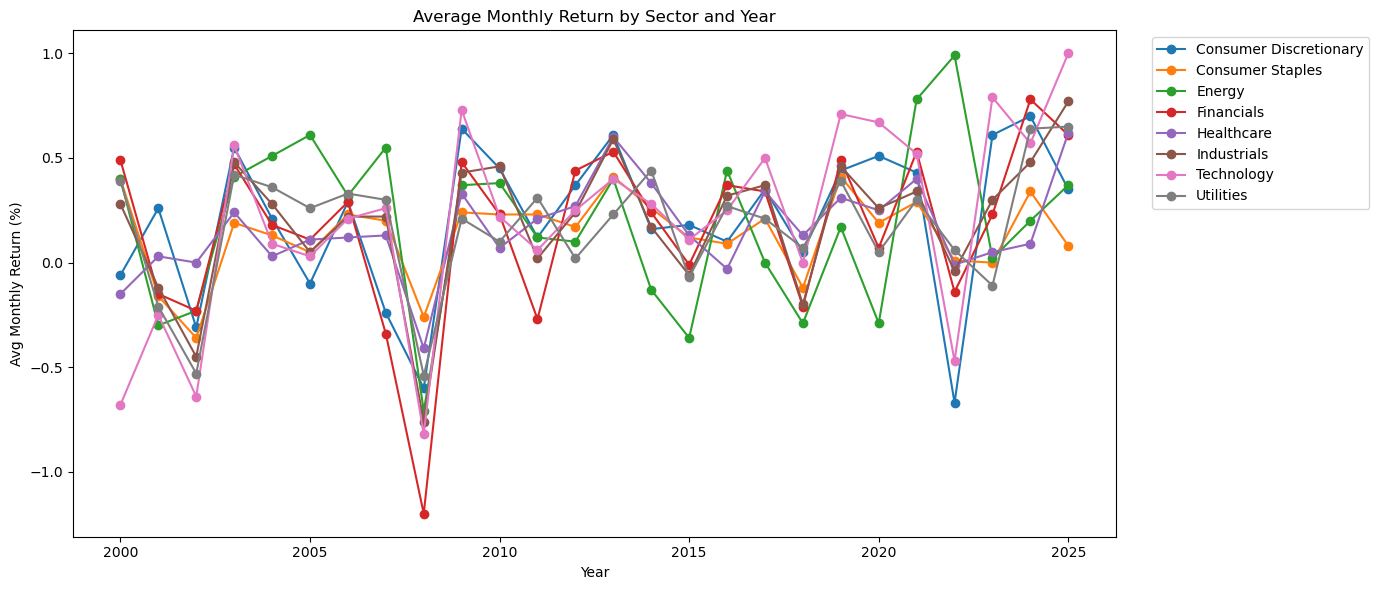

In [15]:
pivot = result.pivot(index='year', columns='sector', values='avg_monthly_return')

pivot.plot(figsize=(14, 6), marker='o', linewidth=1.5)
plt.title('Average Monthly Return by Sector and Year')
plt.xlabel('Year')
plt.ylabel('Avg Monthly Return (%)')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()

### Top Companies by Market Cap Per Sector

In [16]:
result = pd.read_sql_query("""
    SELECT
        sector,
        ticker,
        company_name,
        market_cap,
        RANK() OVER (PARTITION BY sector ORDER BY market_cap DESC) AS rank_in_sector
    FROM companies
    ORDER BY sector, rank_in_sector
""", conn)

print(result)

        sector ticker        company_name  market_cap  rank_in_sector
0       Energy    XOM         Exxon Mobil       440.0               1
1       Energy    CVX             Chevron       320.0               2
2       Energy    COP      ConocoPhillips       130.0               3
3   Financials    JPM      JPMorgan Chase       480.0               1
4   Financials    BAC     Bank of America       280.0               2
5   Financials    WFC         Wells Fargo       180.0               3
6   Healthcare    UNH  UnitedHealth Group       480.0               1
7   Healthcare    JNJ   Johnson & Johnson       430.0               2
8   Healthcare    PFE              Pfizer       160.0               3
9   Technology   AAPL          Apple Inc.      2800.0               1
10  Technology   MSFT           Microsoft      2500.0               2
11  Technology  GOOGL            Alphabet      1700.0               3
12  Technology   NVDA              NVIDIA      1200.0               4


### Macro Data Joined With Sector Performance by Quarter

In [17]:
result = pd.read_sql_query("""
    SELECT
        strftime('%Y', s.date)                      AS year,
        CASE
            WHEN strftime('%m', s.date) IN ('01','02','03') THEN 'Q1'
            WHEN strftime('%m', s.date) IN ('04','05','06') THEN 'Q2'
            WHEN strftime('%m', s.date) IN ('07','08','09') THEN 'Q3'
            WHEN strftime('%m', s.date) IN ('10','11','12') THEN 'Q4'
        END                                         AS quarter,
        s.sector,
        ROUND(AVG(s.pct_change), 2)                 AS avg_sector_return,
        ROUND(AVG(m.cpi), 2)                        AS avg_cpi,
        ROUND(AVG(m.unemployment), 2)               AS avg_unemployment,
        ROUND(AVG(m.fed_funds_rate), 2)             AS avg_fed_funds_rate
    FROM sp500_sectors s
    JOIN macro_indicators m ON strftime('%Y-%m', s.date) = strftime('%Y-%m', m.date)
    WHERE s.pct_change IS NOT NULL
    GROUP BY year, quarter, s.sector
    ORDER BY year, quarter, avg_sector_return DESC
""", conn)

print(result)

     year quarter                  sector  avg_sector_return  avg_cpi  \
0    2000      Q1              Technology               1.35   170.16   
1    2000      Q1  Consumer Discretionary               0.60   170.16   
2    2000      Q1             Industrials               0.58   170.16   
3    2000      Q1                  Energy               0.56   170.16   
4    2000      Q1              Financials               0.51   170.16   
..    ...     ...                     ...                ...      ...   
827  2025      Q4             Industrials               0.17   325.55   
828  2025      Q4                  Energy               0.16   325.55   
829  2025      Q4        Consumer Staples              -0.01   325.55   
830  2025      Q4  Consumer Discretionary              -0.02   325.55   
831  2025      Q4               Utilities              -0.20   325.55   

     avg_unemployment  avg_fed_funds_rate  
0                4.04                5.69  
1                4.04              

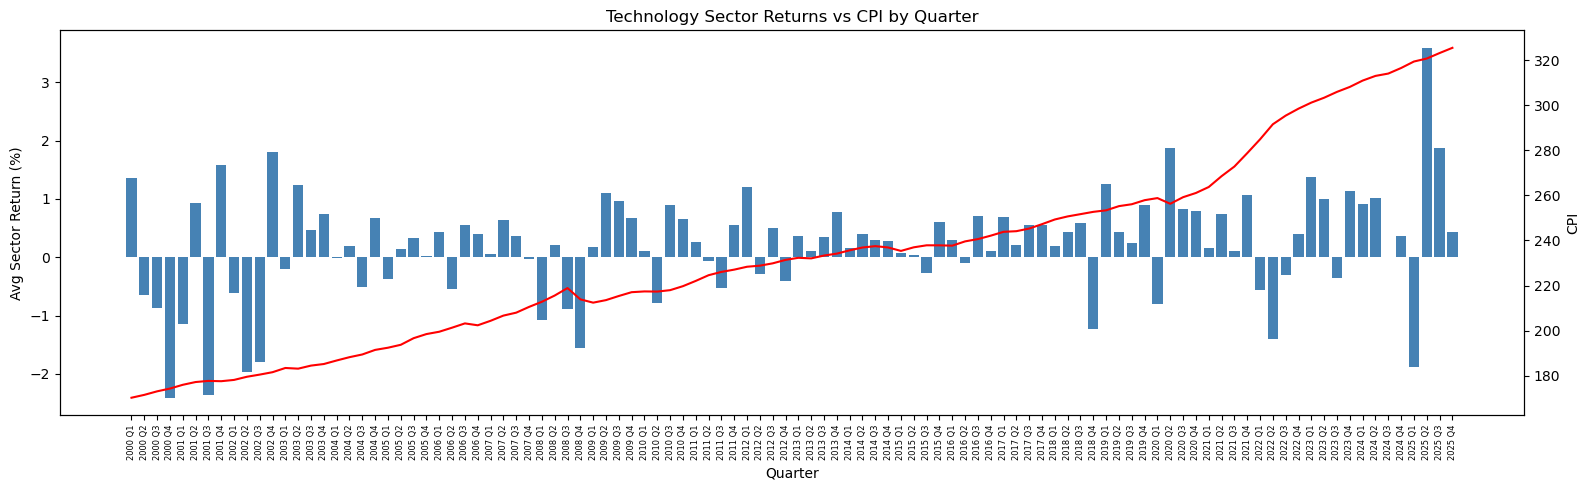

In [18]:
tech = result[result['sector'] == 'Technology'].copy()
tech['period'] = tech['year'] + ' ' + tech['quarter']

fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.bar(tech['period'], tech['avg_sector_return'], color='steelblue', label='Tech Return %')
ax1.set_ylabel('Avg Sector Return (%)')
ax1.set_xlabel('Quarter')
plt.xticks(rotation=90, fontsize=6)

ax2 = ax1.twinx()
ax2.plot(tech['period'], tech['avg_cpi'], color='red', linewidth=1.5, label='CPI')
ax2.set_ylabel('CPI')

plt.title('Technology Sector Returns vs CPI by Quarter')
fig.tight_layout()
plt.show()

### Sectors That Outperform During High Inflation

In [19]:
result = pd.read_sql_query("""
    WITH inflation_periods AS (
        SELECT
            date,
            cpi,
            CASE
                WHEN cpi > (SELECT AVG(cpi) * 1.1 FROM macro_indicators) THEN 'High Inflation'
                ELSE 'Normal'
            END AS inflation_regime
        FROM macro_indicators
    )
    SELECT
        i.inflation_regime,
        s.sector,
        ROUND(AVG(s.pct_change), 2)     AS avg_monthly_return,
        COUNT(s.record_id)              AS months_in_regime
    FROM sp500_sectors s
    JOIN inflation_periods i ON strftime('%Y-%m', s.date) = strftime('%Y-%m', i.date)
    WHERE s.pct_change IS NOT NULL
    GROUP BY i.inflation_regime, s.sector
    ORDER BY i.inflation_regime, avg_monthly_return DESC
""", conn)

print(result)

   inflation_regime                  sector  avg_monthly_return  \
0    High Inflation              Technology                0.40   
1    High Inflation              Financials                0.27   
2    High Inflation             Industrials                0.25   
3    High Inflation                  Energy                0.24   
4    High Inflation  Consumer Discretionary                0.21   
5    High Inflation              Healthcare                0.17   
6    High Inflation               Utilities                0.15   
7    High Inflation        Consumer Staples                0.13   
8            Normal  Consumer Discretionary                0.19   
9            Normal               Utilities                0.16   
10           Normal             Industrials                0.16   
11           Normal                  Energy                0.16   
12           Normal              Healthcare                0.15   
13           Normal        Consumer Staples                0.1

### Rolling 4-Quarter GDP Growth vs Market Returns

In [20]:
result = pd.read_sql_query("""
    WITH quarterly_returns AS (
        SELECT
            strftime('%Y', date)            AS year,
            CASE
                WHEN strftime('%m', date) IN ('01','02','03') THEN 'Q1'
                WHEN strftime('%m', date) IN ('04','05','06') THEN 'Q2'
                WHEN strftime('%m', date) IN ('07','08','09') THEN 'Q3'
                WHEN strftime('%m', date) IN ('10','11','12') THEN 'Q4'
            END                             AS quarter,
            sector,
            ROUND(AVG(pct_change), 2)       AS avg_quarterly_return
        FROM sp500_sectors
        WHERE pct_change IS NOT NULL
        GROUP BY year, quarter, sector
    ),
    gdp_quarterly AS (
        SELECT
            strftime('%Y', date)            AS year,
            CASE
                WHEN strftime('%m', date) IN ('01','02','03') THEN 'Q1'
                WHEN strftime('%m', date) IN ('04','05','06') THEN 'Q2'
                WHEN strftime('%m', date) IN ('07','08','09') THEN 'Q3'
                WHEN strftime('%m', date) IN ('10','11','12') THEN 'Q4'
            END                             AS quarter,
            gdp_growth
        FROM macro_indicators
        WHERE gdp_growth IS NOT NULL
    ),
    gdp_with_rolling AS (
        SELECT
            year,
            quarter,
            gdp_growth,
            ROUND(AVG(gdp_growth) OVER (
                ORDER BY year, quarter
                ROWS BETWEEN 3 PRECEDING AND CURRENT ROW
            ), 2)                           AS rolling_4q_gdp
        FROM gdp_quarterly
    )
    SELECT
        q.year,
        q.quarter,
        q.sector,
        q.avg_quarterly_return,
        g.rolling_4q_gdp
    FROM quarterly_returns q
    JOIN gdp_with_rolling g ON q.year = g.year AND q.quarter = g.quarter
    WHERE g.rolling_4q_gdp IS NOT NULL
    ORDER BY q.year, q.quarter, q.avg_quarterly_return DESC
""", conn)

print(result)

     year quarter                  sector  avg_quarterly_return  \
0    2000      Q1              Technology                  1.35   
1    2000      Q1  Consumer Discretionary                  0.60   
2    2000      Q1             Industrials                  0.58   
3    2000      Q1                  Energy                  0.56   
4    2000      Q1              Financials                  0.51   
..    ...     ...                     ...                   ...   
827  2025      Q4             Industrials                  0.17   
828  2025      Q4                  Energy                  0.16   
829  2025      Q4        Consumer Staples                 -0.01   
830  2025      Q4  Consumer Discretionary                 -0.02   
831  2025      Q4               Utilities                 -0.20   

     rolling_4q_gdp  
0              1.50  
1              1.50  
2              1.50  
3              1.50  
4              1.50  
..              ...  
827            2.25  
828            2.25

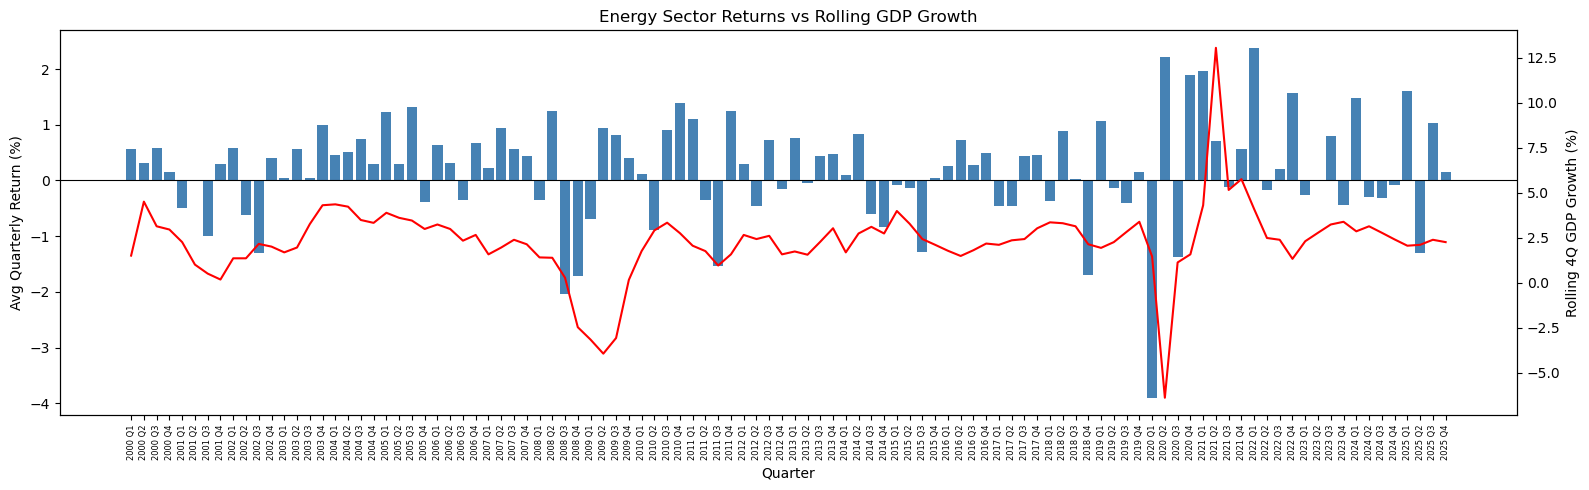

In [21]:
energy = result[result['sector'] == 'Energy'].copy()
energy['period'] = energy['year'] + ' ' + energy['quarter']

fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.bar(energy['period'], energy['avg_quarterly_return'],
        color='steelblue', label='Energy Return %')
ax1.set_ylabel('Avg Quarterly Return (%)')
ax1.set_xlabel('Quarter')
ax1.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=90, fontsize=6)

ax2 = ax1.twinx()
ax2.plot(energy['period'], energy['rolling_4q_gdp'],
         color='red', linewidth=1.5, label='Rolling 4Q GDP')
ax2.set_ylabel('Rolling 4Q GDP Growth (%)')

plt.title('Energy Sector Returns vs Rolling GDP Growth')
fig.tight_layout()
plt.show()

### Sector Rankings by Return/Volatility Ratio Per Economic Cycle

In [22]:
result = pd.read_sql_query("""
    WITH economic_cycles AS (
        SELECT
            strftime('%Y', date)        AS year,
            CASE
                WHEN strftime('%m', date) IN ('01','02','03') THEN 'Q1'
                WHEN strftime('%m', date) IN ('04','05','06') THEN 'Q2'
                WHEN strftime('%m', date) IN ('07','08','09') THEN 'Q3'
                WHEN strftime('%m', date) IN ('10','11','12') THEN 'Q4'
            END                         AS quarter,
            CASE
                WHEN gdp_growth < 0                 THEN 'Contraction'
                WHEN gdp_growth BETWEEN 0 AND 2     THEN 'Slow Growth'
                WHEN gdp_growth BETWEEN 2 AND 4     THEN 'Moderate Growth'
                ELSE 'Strong Growth'
            END                         AS economic_cycle
        FROM macro_indicators
        WHERE gdp_growth IS NOT NULL
    ),
    sector_stats AS (
        SELECT
            strftime('%Y', s.date)                      AS year,
            CASE
                WHEN strftime('%m', s.date) IN ('01','02','03') THEN 'Q1'
                WHEN strftime('%m', s.date) IN ('04','05','06') THEN 'Q2'
                WHEN strftime('%m', s.date) IN ('07','08','09') THEN 'Q3'
                WHEN strftime('%m', s.date) IN ('10','11','12') THEN 'Q4'
            END                                         AS quarter,
            s.sector,
            AVG(s.pct_change)                           AS avg_return,
            MAX(s.pct_change) - MIN(s.pct_change)       AS return_range
        FROM sp500_sectors s
        WHERE s.pct_change IS NOT NULL
        GROUP BY year, quarter, s.sector
    ),
    cycle_performance AS (
        SELECT
            e.economic_cycle,
            ss.sector,
            ROUND(AVG(ss.avg_return), 2)                        AS avg_return,
            ROUND(AVG(ss.return_range), 2)                      AS avg_volatility,
            ROUND(AVG(ss.avg_return) /
                NULLIF(AVG(ss.return_range), 0), 4)             AS return_volatility_ratio
        FROM sector_stats ss
        JOIN economic_cycles e ON ss.year = e.year AND ss.quarter = e.quarter
        GROUP BY e.economic_cycle, ss.sector
    )
    SELECT
        economic_cycle,
        sector,
        avg_return,
        avg_volatility,
        return_volatility_ratio,
        RANK() OVER (
            PARTITION BY economic_cycle
            ORDER BY return_volatility_ratio DESC
        )                                                       AS sector_rank
    FROM cycle_performance
    ORDER BY economic_cycle, sector_rank
""", conn)

print(result)

     economic_cycle                  sector  avg_return  avg_volatility  \
0       Contraction        Consumer Staples       -0.09            6.94   
1       Contraction              Healthcare       -0.13           10.56   
2       Contraction                  Energy       -0.24           16.82   
3       Contraction               Utilities       -0.14            8.44   
4       Contraction  Consumer Discretionary       -0.36           14.85   
5       Contraction              Financials       -0.49           14.24   
6       Contraction             Industrials       -0.47           13.05   
7       Contraction              Technology       -0.52           13.94   
8   Moderate Growth             Industrials        0.33            8.45   
9   Moderate Growth  Consumer Discretionary        0.32            8.30   
10  Moderate Growth              Technology        0.35            9.79   
11  Moderate Growth               Utilities        0.23            7.40   
12  Moderate Growth      

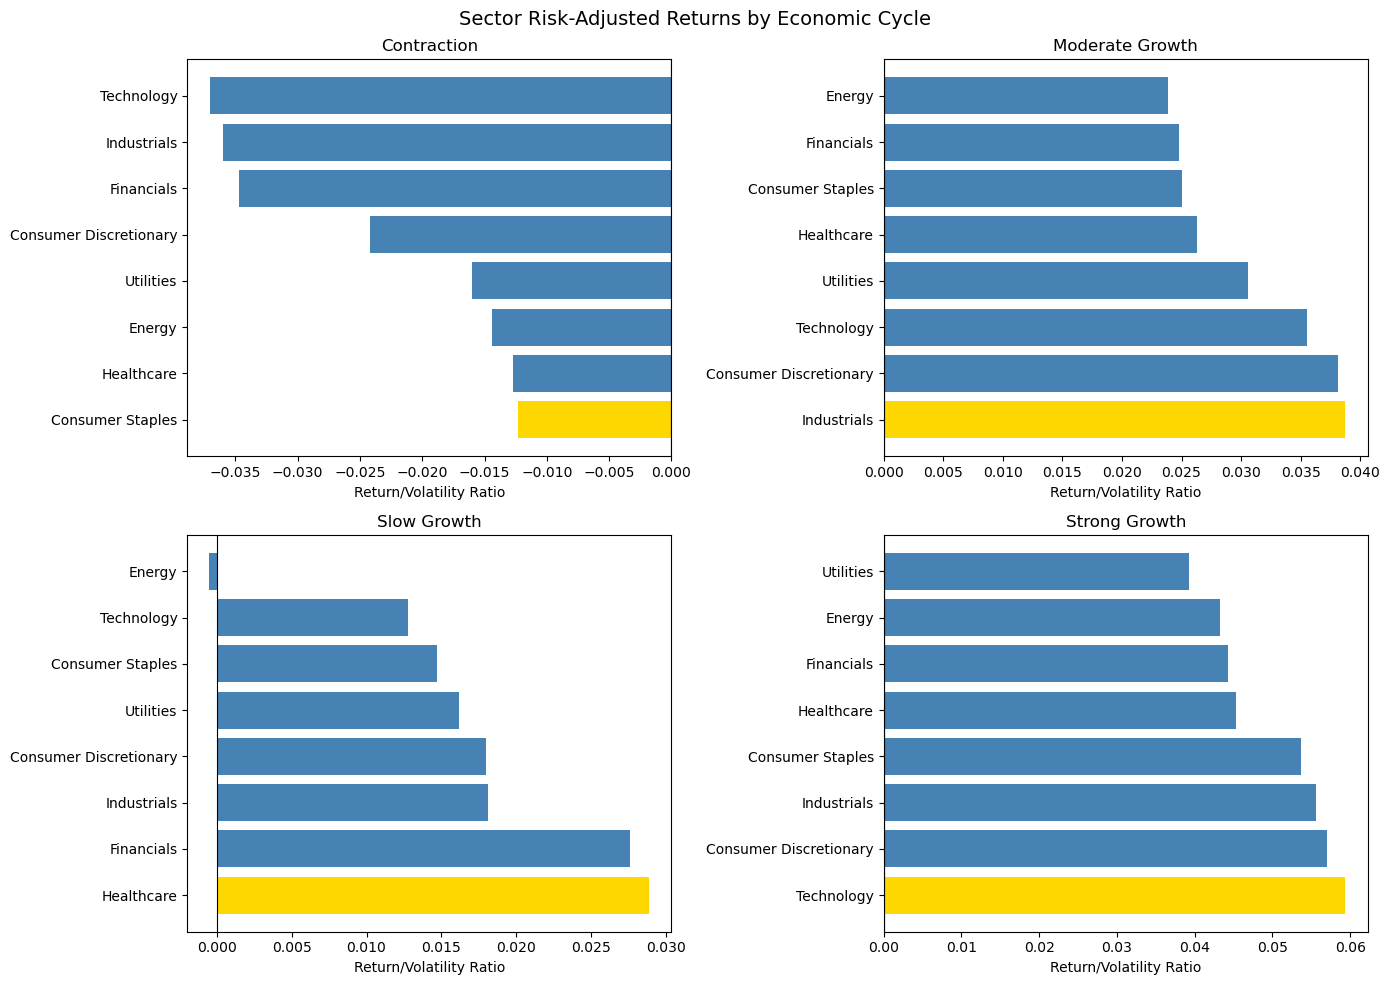

In [23]:
cycles = result['economic_cycle'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cycle in enumerate(cycles):
    subset = result[result['economic_cycle'] == cycle].sort_values('sector_rank')
    colors = ['gold' if r == 1 else 'steelblue' for r in subset['sector_rank']]
    axes[i].barh(subset['sector'], subset['return_volatility_ratio'], color=colors)
    axes[i].set_title(f'{cycle}')
    axes[i].set_xlabel('Return/Volatility Ratio')
    axes[i].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Sector Risk-Adjusted Returns by Economic Cycle', fontsize=14)
plt.tight_layout()
plt.show()